In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [25]:
# part 1

# exponential using inverse formula 
def sample_exponential(lam):
    U = np.random.uniform()
    return -np.log(U) / lam

# normal using box muller 
def sample_normal(mu, sigma):
    U1 = np.random.uniform()
    U2 = np.random.uniform()

    R = np.sqrt(-2 * np.log(U1))
    theta = 2 * np.pi * U2

    Z1 = R * np.cos(theta)
    # we want to sample just one, so we don't get the Z2 value using the sin

    return mu + sigma * Z1

# pareto using inverse
def sample_pareto(k, beta = 1):
    U = np.random.uniform()
    return beta * U**(-1/k)

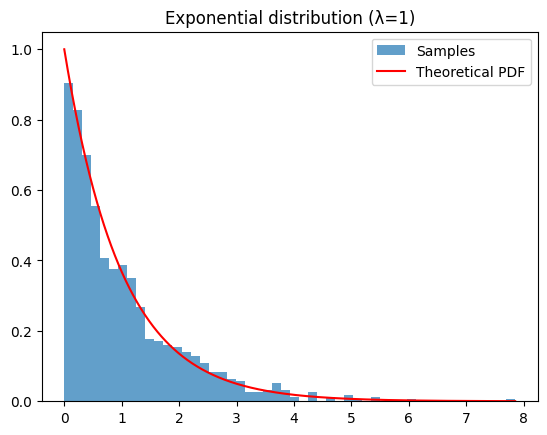

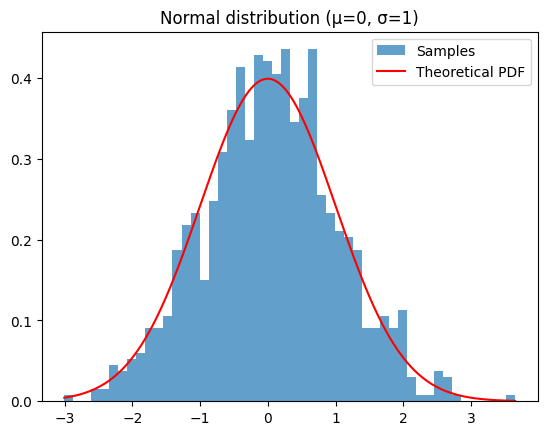

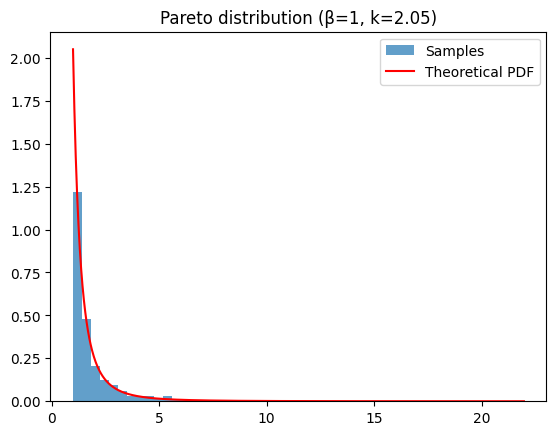

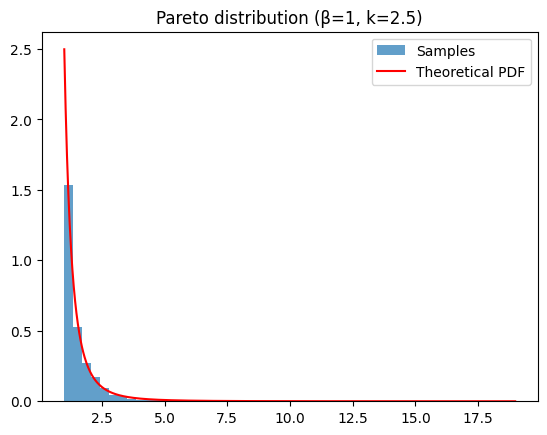

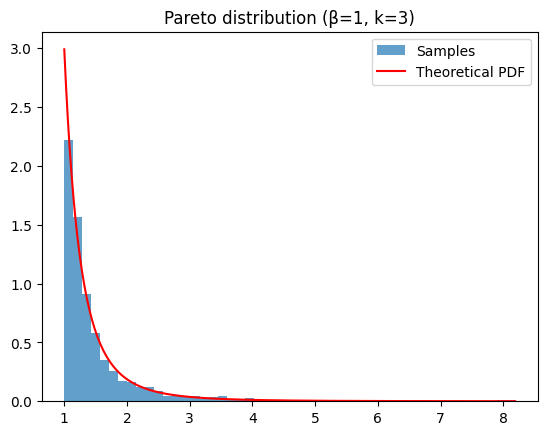

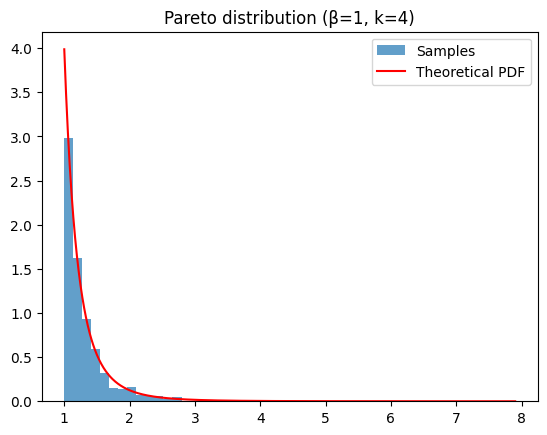

In [4]:
N = 1000

# eponential
exp_samples = [sample_exponential(lam=1) for _ in range(N)]

plt.figure()
plt.hist(exp_samples, bins=50, density=True, alpha=0.7, label='Samples')
x = np.linspace(min(exp_samples), max(exp_samples), 1000)
plt.plot(x, stats.expon(scale=1).pdf(x), 'r-', label='Theoretical PDF')
plt.title('Exponential distribution (λ=1)')
plt.legend()
plt.show()

# normal 
normal_samples = [sample_normal(mu=0, sigma=1) for _ in range(N)]

plt.figure()
plt.hist(normal_samples, bins=50, density=True, alpha=0.7, label='Samples')
x = np.linspace(min(normal_samples), max(normal_samples), 1000)
plt.plot(x, stats.norm(loc=0, scale=1).pdf(x), 'r-', label='Theoretical PDF')
plt.title('Normal distribution (μ=0, σ=1)')
plt.legend()
plt.show()

# pareto 
k_values = [2.05, 2.5, 3, 4]

for k in k_values:
    pareto_samples = [sample_pareto(beta=1, k=k) for _ in range(N)]
    plt.figure()
    plt.hist(pareto_samples, bins=50, density=True, alpha=0.7, label='Samples')
    x = np.linspace(min(pareto_samples), max(pareto_samples), 1000)
    plt.plot(x, stats.pareto(b=k).pdf(x), 'r-', label='Theoretical PDF')
    plt.title(f'Pareto distribution (β=1, k={k})')
    plt.legend()
    plt.show()

In [26]:
# part 2

beta = 1
k_values = [2.05, 2.5, 3, 4]
N = 10000

for k in k_values:
    samples = [sample_pareto(beta=1, k=k) for _ in range(N)]
    
    sample_mean = np.mean(samples)
    sample_var  = np.var(samples)
    
    theoretical_mean = beta * k / (k - 1)
    theoretical_var = beta**2 * k / ((k - 1)**2 * (k - 2)) 
    
    print(f"k={k}: sample mean={sample_mean}, theoretical mean={theoretical_mean}")
    print(f"k={k}: sample var={sample_var},  theoretical var={theoretical_var}")

# For large k (3, 4), sample statistics are close to the theoretical values. 
# For smaller k (2.05, 2.5), discrepancies are large because the Pareto distribution has heavy tails, 
# which means really big values can happen with a significant probability. 
# In a finite sample, these values appear less often, which leads to slow onvergence of the sample mean and variance. 

k=2.05: sample mean=1.9383475379452153, theoretical mean=1.9523809523809526
k=2.05: sample var=6.009696703524775,  theoretical var=37.18820861678019
k=2.5: sample mean=1.6816476834027763, theoretical mean=1.6666666666666667
k=2.5: sample var=2.5388189434423376,  theoretical var=2.2222222222222223
k=3: sample mean=1.497131222645634, theoretical mean=1.5
k=3: sample var=0.7588327337701501,  theoretical var=0.75
k=4: sample mean=1.3295107058712226, theoretical mean=1.3333333333333333
k=4: sample var=0.21318368794164977,  theoretical var=0.2222222222222222


In [21]:
# part 3

n = 10
n_intervals = 100
true_mean = 0
true_var  = 1

mean_count = 0
var_count = 0

for _ in range(n_intervals):
    sample = [sample_normal(mu=0, sigma=1) for _ in range(n)]
    
    xbar = np.mean(sample)
    s2   = np.var(sample, ddof=1)
    
    # for mean we use t critical value
    t_crit = stats.t.ppf(0.975, df=n-1)
    mean_lower = xbar - t_crit * np.sqrt(s2) / np.sqrt(n)
    mean_upper = xbar + t_crit * np.sqrt(s2) / np.sqrt(n)

    # for variance we use chi2 critical values
    chi2_lower = stats.chi2.ppf(0.025, df=n-1)
    chi2_upper = stats.chi2.ppf(0.975, df=n-1)
    var_lower = (n - 1) * s2 / chi2_upper
    var_upper = (n - 1) * s2 / chi2_lower

    mean_covered = mean_lower <= true_mean <= mean_upper
    var_covered  = var_lower  <= true_var  <= var_upper

    if mean_lower <= true_mean <= mean_upper:
        mean_count += 1

    if var_lower <= true_var <= var_upper:
        var_count += 1

print(f"Mean CI coverage: {mean_count}")
print(f"Var  CI coverage: {var_count}")

# We should get approximately 95/100 confidence intervals containing the true value when there are 100 
# confidence intervals at 95% confidence, which in fact is what we observe here.

Mean CI coverage: 95
Var  CI coverage: 93


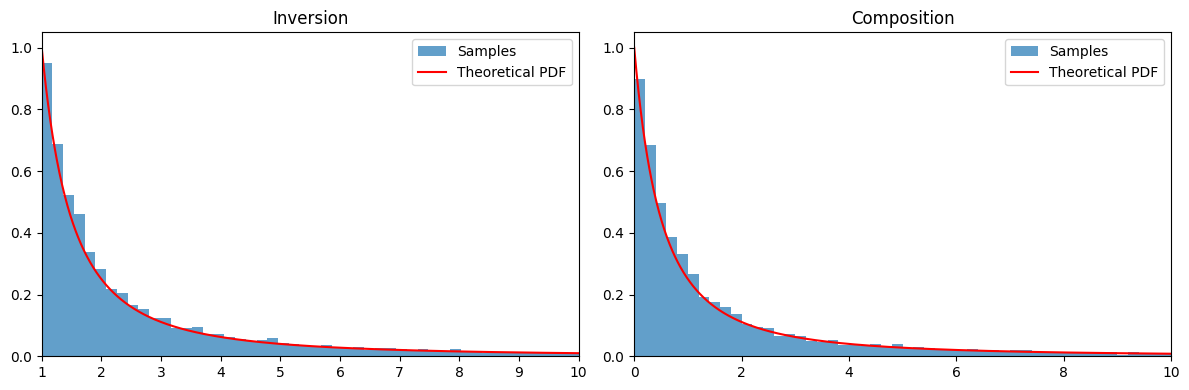

In [24]:
# part 4
def sample_pareto_composition(mu):
    y = sample_exponential(lam=mu)
    x = sample_exponential(lam=y)
    return x

N = 10000
mu = 1

samples_inversion   = [sample_pareto(beta=1, k=1) for _ in range(N)]
samples_composition = [sample_pareto_composition(mu=1) for _ in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# inversion method on [1, inf)
x1 = np.linspace(1, 10, 1000)
axes[0].hist(samples_inversion, bins=50, density=True, alpha=0.7, range=(1, 10), label='Samples')
axes[0].plot(x1, stats.pareto(b=1).pdf(x1), 'r-', label='Theoretical PDF')
axes[0].set_xlim(1, 10)
axes[0].set_title('Inversion')
axes[0].legend()

# composition method on [0, inf)
x2 = np.linspace(0, 10, 1000)
axes[1].hist(samples_composition, bins=50, density=True, alpha=0.7, range=(0, 10), label='Samples')
axes[1].plot(x2, mu / (mu + x2)**2, 'r-', label='Theoretical PDF')
axes[1].set_xlim(0, 10)
axes[1].set_title('Composition')
axes[1].legend()

plt.tight_layout()
plt.show()